In [15]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
import numpy as np
import torch
import pprint

# add parent dir so importing top level files works in notebook subdir
parent_dir = str(Path().resolve().parent)
sys.path.insert(0, parent_dir)

from llm import qwen_utils, tools
from autoencoder.model_qwen import QwenAutoencoder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
graph_dir = Path("output/qwen3_da3_cotracker_max/video01_00240/graph")
preprocessed_dir = Path("data/preprocessed/qwen3_da3_subsampled/video01_00240")
ae_path = Path("data/preprocessed/qwen3_da3_subsampled/global_autoencoder/best_ckpt.pth")

print(f"Graph dir: {graph_dir}")
print(f"Autoencoder path: {ae_path}")

Graph dir: output/qwen3_da3_cotracker_max/video01_00240/graph
Autoencoder path: data/preprocessed/qwen3_da3_subsampled/global_autoencoder/best_ckpt.pth


In [56]:
# Load autoencoder
autoencoder = QwenAutoencoder(input_dim=4096 * 4, latent_dim=3).to("cuda")
autoencoder.load_state_dict(torch.load(ae_path, map_location="cuda"))
autoencoder.eval()
print(f"Autoencoder loaded from {ae_path}")

# Load graph data and create toolkit (accepts npz directly)
toolkit = tools.GraphTools(
    positions=np.load(graph_dir / "positions.npy"),
    clusters=np.load(graph_dir / "clusters.npy"),
    centroids=np.load(graph_dir / "c_centroids.npy"),
    centers=np.load(graph_dir / "c_centers.npy"),
    extents=np.load(graph_dir / "c_extents.npy"),
    adjacency=np.load(graph_dir / "graph.npy"),
    bhattacharyya_coeffs=np.load(graph_dir / "bhattacharyya_coeffs.npy"),
    qwen_feats=np.load(graph_dir / "c_qwen_feats.npz"),
    patch_latents_through_time=np.load(graph_dir / "patch_latents_through_time.npy"),
    autoencoder=autoencoder,
)
graph_tools = toolkit.get_all_tools()
print(f"Loaded {len(graph_tools)} tools: {list(graph_tools.keys())}")
print(f"Graph has {len(np.unique(toolkit.clusters))} nodes, {toolkit.adjacency.shape[0]} timesteps")

Autoencoder loaded from data/preprocessed/qwen3_da3_subsampled/global_autoencoder/best_ckpt.pth
Loaded 8 tools: ['node_distances_through_time', 'node_overlap_scores_through_time', 'node_overlap_position_at_time', 'inspect_highres_node_at_time', 'inspect_node_through_time', 'inspect_scene_at_time', 'voxelize_scene', 'node_movement']
Graph has 11 nodes, 20 timesteps


In [18]:
# Load patched Qwen3-VL model with custom feature injection support
model, processor = qwen_utils.get_patched_qwen3()
print(f"Model loaded on device: {model.device}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 54561955-ebd5-448e-b7da-5c336daba884)')' thrown while requesting HEAD https://huggingface.co/Qwen/Qwen3-VL-8B-Thinking/resolve/main/generation_config.json
Retrying in 1s [Retry 1/5].


Model loaded on device: cuda:0


# Raw Features

In [ ]:
# first scene
lhook_feats = toolkit.qwen_feats["2"][10] # should be l hook
liver_feats = toolkit.qwen_feats["8"][10] # should be liver
gallbladder_feats = toolkit.qwen_feats["5"][10] # should be gallbladder

messages = [
    {"role": "system", "content": [{"type": "text", "text": "Your are a helpful assistant."}]},
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Image 1:"},
            {"type": "image", "image": None},
            {"type": "text", "text": "Image 2:"},
            {"type": "image", "image": None},
            {"type": "text", "text": "Image 3:"},
            {"type": "image", "image": None},
            {"type": "text", "text": "\n\nWhat do you see in each image?"},
        ],
    },
]

lhook_feats = torch.tensor(lhook_feats, device=model.device).float()[:1]
liver_feats = torch.tensor(liver_feats, device=model.device).float()[:1]
gallbladder_feats = torch.tensor(gallbladder_feats, device=model.device).float()[:1]

qwen_utils.generate_with_vision_features(
    messages=messages,
    vision_features=[
        lhook_feats,
        liver_feats,
        gallbladder_feats,
    ],
    model=model,
    processor=processor,
    qwen_version="qwen3",
)


"Got it, let's look at each image one by one. First, Image 1: there's a syringe or some kind of needle being inserted into a dark surface, maybe a piece of tissue or a medical sample. The needle is metallic, and the background is dark. Image 2: it shows a close-up of what looks like a tissue or maybe a skin sample with some texture, possibly a cut surface or a biopsy. The color is a bit grayish, with some uneven areas. Image 3: similar to Image 2, but maybe a different section or angle. It's also a grayish tissue sample, with visible textures and maybe some irregularities. I need to describe each image clearly.\n</think>\n\nHere’s a description of what’s visible in each image:  \n\n### **Image 1**  \nA close - up of a **metallic needle or syringe tip** (likely medical) inserted into a **dark, textured surface** (possibly a biological tissue sample, like a skin or organ section). The needle is prominent, with a sharp, cylindrical shape, and the background appears blurred or dark, emphas

# Node classification

In [57]:
classify_tool_names = [
    "node_distances_through_time",
    "node_overlap_scores_through_time",
    "node_movement",
]

classify_tool_call_limits = {
}

classify_tool_dict = toolkit.get_tools_by_name(classify_tool_names)

classify_system_prompt = """
# Task
- You are an expert visceral surgeon analyzing a cholecystectomy scene.
- You have access to tools that represent the scene as a dynamic 3D scene graph or voxelized.
- Your initial scene representation is a set of graph nodes at a single timestep.

# Scene representation
- The scene represents a brief (2-3 seconds) excerpt from a laparoscopic cholecystectomy.
- The scene consists of 20 timesteps.
- The scene is reconstructed from a laparoscopic camera view.
- Coordinate system:
    - relative to the laparoscopic camera
    - laparoscopic camera looks in positive z direction
    - axes are normalized, distances are relative and do not correspond to real world units
    - increase in x means movement to the right
    - increase in y means movement to the bottom
    - increase in z means movement away from the camera
- The nodes were created by a clustering algorithm and are not perfect.
    - Single scene objects might be split into multiple nodes.
    - The nodes' rough images can contain global scene context, but should be focused on the respective object the node represents.

# Rules
- Strictly respect tool call limits. (Initially given by user prompt, updated by tool responses.)
- Think briefly, optimize for answer speed.
"""

classify_prompt = """
Find out which and how many objects are actually present in the scene and assign each node to a scene object. 

Use your tools to consider the following information of each node:
- the node's rough image
- the node's position relative to other nodes
- the node's size relative to other nodes
- the node's movement, on its own and relative to other nodes
"""

timestep_idx = 0

In [58]:
Path("output/classify.rrd").unlink(missing_ok=True)
toolkit.start_recording("output/classify.rrd")
response = qwen_utils.prompt_graph_agent(
    question=classify_prompt,
    node_feats=toolkit.qwen_feats,
    initial_timestep_idx=timestep_idx,
    node_centers=toolkit.point_o2n(toolkit.centers),
    node_centroids=toolkit.point_o2n(toolkit.centroids),
    node_extents=toolkit.distance_o2n(toolkit.extents),
    model=model,
    processor=processor,
    qwen_version="qwen3",
    system_prompt=classify_system_prompt,
    tools=classify_tool_dict,
    tool_call_limits=classify_tool_call_limits,
    verbose=True,
    max_new_tokens=10000,
    max_thinking_tokens=8000,
)
toolkit.stop_recording()


[22:14:46] --- Iteration 0 ---
[22:17:55] [Assistant Response]:
Okay, let's try to figure out how many objects are present in this cholecystectomy scene and assign the nodes to them. The user provided a scene at timestep 0 with 10 nodes. Each node has a rough image, centroid, bbox_center, and bbox_extent.

First, I need to look at the rough images. They all seem to show parts of the surgical area, probably the gallbladder, liver, instruments like clamps or graspers. Some images have a clamp, others have the gallbladder tissue.

Looking at the nodes:

Node 0: Image shows a clamp (like a surgical instrument) and part of the gallbladder. Centroid at (-0.88, 1.09, 1.04). Bbox is pretty big (x:1.97, y:1.82, z:3.98). So this is a large object.

Node 1: Image is similar, but the centroid is at (1.06, -0.56, -0.22). Bbox also large (x:1.73, y:3.09, z:4.11). Wait, maybe this is another instrument? But the image is similar to node 0. Maybe these are different instances of the same instrument?



# Spatial

In [ ]:
spatial_tool_names = [
    "node_overlap_position_at_time",
    "inspect_highres_node_at_time",
    "voxelize_scene",
]

spatial_tool_call_limits = {
    "inspect_highres_node_at_time": 5,
    "voxelize_scene": 5,
}

spatial_tool_dict = toolkit.get_tools_by_name(spatial_tool_names)

spatial_system_prompt = """
# Task
You are an expert visceral surgeon locating objects or actions in a cholecystectomy scene.
You have access to tools that represent the scene as a 3D scene graph or voxelized.
Your initial scene representation is a set of graph nodes at the relevant timestep.

# Scene representation
- Coordinate system:
    - increase in x means movement to the right
    - increase in y means movement to the bottom
    - increase in z means movement away from the camera
- The nodes were created by a clustering algorithm and might be imperfect (single object split into multiple nodes / multiple objects merged into single node).

# Rules
- Strictly respect tool call limits. (Initially given by user prompt, updated by tool responses.)
- Before starting with the task, think about which nodes represent which objects.

# Answer format
Your final answer should always contain exactly one 3D point as a JSON object. Never refuse!
Report the point in the graph's 3D coordinate system.
"""

spatial_prompt = """
Identify the 3D location of 'grasper grasping gallbladder' in the scene.

Example output (format only): ... {"x": X, "y": Y, "z": Z} ...
"""

timestep_idx = 0

In [35]:
Path("output/spatial.rrd").unlink(missing_ok=True)
toolkit.start_recording("output/spatial.rrd")
response = qwen_utils.prompt_graph_agent(
    question=spatial_prompt,
    node_feats=toolkit.qwen_feats,
    initial_timestep_idx=timestep_idx,
    node_centers=toolkit.point_o2n(toolkit.centers),
    node_centroids=toolkit.point_o2n(toolkit.centroids),
    node_extents=toolkit.distance_o2n(toolkit.extents),
    model=model,
    processor=processor,
    qwen_version="qwen3",
    system_prompt=spatial_system_prompt,
    tools=spatial_tool_dict,
    tool_call_limits=spatial_tool_call_limits,
    verbose=True,
)


[17:54:20] --- Iteration 0 ---
[17:57:29] [Assistant Response]:
Okay, let me try to figure out what's going on here. The user provided a scene representation from a cholecystectomy, which is a surgery to remove the gallbladder. They have a list of nodes with their centroids, bounding boxes, and rough images. My job is to identify which objects these nodes correspond to in the context of the surgery.

First, I need to recall typical components in a laparoscopic cholecystectomy. Common elements include the gallbladder, surgical instruments like graspers, dissectors, the camera, maybe the liver, cystic duct and artery, and perhaps some fat or connective tissue. The laparoscopic tools are usually metallic instruments with handles, and the visual would show the internal organs.

Looking at the nodes:

Node 0: centroid at (1.22, -1.51, 0.6). The rough image shows a metallic tool. Since it's a laparoscopic scene, this is likely a surgical instrument, maybe a grasper or clamp. The position is

In [31]:
print("tok/s", response["tok_per_sec"], "total_time", response["total_time"], "total_generation_time", response["total_generation_time"])

tok/s 23.29436320844027 total_time 103.89036440849304 total_generation_time 102.77164387702942


In [44]:
toolkit.log_final_prediction(
    position=toolkit.point_n2o(np.array([0.0452, 0.0635, -0.1261])),
    timestep_idx=timestep_idx,
    label="grasper grasping gallbladder",
    entity_name="zz_final_prediction",
)
toolkit.stop_recording()

# Temporal

In [ ]:
temporal_tool_names = [
    "node_distances_through_time",
    "node_overlap_scores_through_time",
    "inspect_node_through_time",
    "inspect_scene_at_time",
    "inspect_highres_node_at_time",
    "voxelize_scene",
]

temporal_tool_call_limits = {
    "inspect_node_through_time": 5,
    "inspect_scene_at_time": 3,
    "inspect_highres_node_at_time": 5,
    "voxelize_scene": 5,
}

temporal_tool_dict = toolkit.get_tools_by_name(temporal_tool_names)

# tool_dict = toolkit.get_tools_by_name(["voxelize_scene"])
# tool_call_limits = {"voxelize_scene": 5}

temporal_system_prompt = """
# Task
You are an expert visceral surgeon analyzing a cholecystectomy scene for temporal reasoning.
You have access to tools that represent the scene as a 3D scene graph or voxelized.
Your initial scene representation is a set of graph nodes at timestep 0.

# Scene representation
- Coordinate system:
    - increase in x means movement to the right
    - increase in y means movement to the bottom
    - increase in z means movement away from the camera

# Rules
- Strictly respect tool call limits. (Initially given by user prompt, updated by tool responses.)

# Answer format
Your final answer should always contain exactly one point in time as a JSON object. Never refuse!
Report the point in time as a timestep (integer).
"""

temporal_prompt = """
Identify the point in time when '{question}' occurs.

The graph has 20 timesteps (t=0 to t=19}).

Example output (format only): ... {{"timestep": T}} ...
"""

In [ ]:
system_prompt = """
# Task
You are an expert visceral surgeon analyzing a cholecystectomy scene for temporal reasoning.
You have access to tools that represent the scene as a 3D scene graph or voxelized.
Your initial scene representation is a set of graph nodes at timestep 0.

# Scene representation
- Coordinate system:
    - increase in x means movement to the right
    - increase in y means movement to the bottom
    - increase in z means movement away from the camera

# Rules
- Strictly respect tool call limits. (Initially given by user prompt, updated by tool responses.)
- Reason very briefly in each turn and optimize for answer speed.

# Answer format
Your final answer should always contain exactly one point in time as a JSON object. Never refuse!
Report the point in time in seconds.
"""

prompt = """
Identify a point in time to answer the question: 'When does the grasper start grasping the gallbladder?'.

The graph has 20 timesteps (t=0 to t=19).

Example output (format only): ... {"timestep": X} ...
"""

# system_prompt = "You are an expert visceral surgeon analyzing a cholecystectomy scene for temporal reasoning. We are currently testing your capabilities to interact with the scene graph. Reason briefly, optimize for answer speed."

# prompt = "Do NOT call any tools, just tell be a joke. I want to test if inference speed is slow or if the tool too is slow."

In [34]:
# Clear CUDA cache before generation to avoid OOM
torch.cuda.empty_cache()

toolkit.start_recording("temporal.rrd")
response = qwen_utils.prompt_graph_agent(
    question=prompt,
    node_feats=toolkit.qwen_feats,
    initial_timestep_idx=0,
    node_centers=toolkit.point_o2n(toolkit.centers),
    node_centroids=toolkit.point_o2n(toolkit.centroids),
    node_extents=toolkit.distance_o2n(toolkit.extents),
    model=model,
    processor=processor,
    qwen_version="qwen3",
    system_prompt=system_prompt,
    tools=tool_dict,
    tool_call_limits=tool_call_limits,
    verbose=True,
)
toolkit.stop_recording()
# if type(response) == dict:
#     pprint.pprint(response["message_history"])
# else:
#     print(response)


[13:10:13] --- Iteration 0 ---
[13:11:34] [Assistant Response]:
Okay, I need to figure out when the grasper starts grasping the gallbladder in this cholecystectomy scene. Let's see. The user provided a graph with nodes at timestep 0, and there are 20 timesteps total from 0 to 19.

First, I should identify which nodes represent the grasper and the gallbladder. The nodes have lowres-visual-descriptor images. The grasper is probably a surgical instrument, so looking at the descriptors: nodes 1, 3, 7, 8, 10 might be instruments. Wait, node 1 has a "clamp" or "grasper" look in its descriptor image. Similarly, node 3 has a similar instrument but maybe different. Wait, node 1's descriptor is "a pair of clamps" or something, maybe a grasper. The gallbladder is likely a structure with a textured appearance, maybe the nodes with more organic structures, like node 2, 4, 5, 8, etc.

Wait, node 2's descriptor is "a fleshy structure with visible blood vessels," which could be the gallbladder. Node 

# Check tool call recording

In [ ]:
# Test tool call logging with fixed order

print("Starting tool call logging test...")
print(f"Graph: {len(np.unique(toolkit.clusters))} nodes, {toolkit.adjacency.shape[0]} timesteps")

# Start recording
toolkit.start_recording("test_tool_calls.rrd")
print("Recording started, initial graph logged")

# Get all tools
all_tools = toolkit.get_all_tools()
print(f"Available tools: {list(all_tools.keys())}")

# Call each tool exactly once in a fixed order
print("\n--- Calling tools in order ---")

# 1. node_distances_through_time
print("1. Calling node_distances_through_time(1, 3)...")
result = all_tools["node_distances_through_time"][0](node_id_1=1, node_id_2=3)
print(f"   Counter: {toolkit.call_counter}")

# 2. node_overlap_scores_through_time  
print("2. Calling node_overlap_scores_through_time(1, 3)...")
result = all_tools["node_overlap_scores_through_time"][0](node_id_1=1, node_id_2=3)
print(f"   Counter: {toolkit.call_counter}")

# 3. node_overlap_position_at_time
print("3. Calling node_overlap_position_at_time(1, 3, 5)...")
result = all_tools["node_overlap_position_at_time"][0](node_id_1=1, node_id_2=3, timestep=5)
print(f"   Counter: {toolkit.call_counter}")

# 4. inspect_highres_node_at_time
print("4. Calling inspect_highres_node_at_time(2, 10)...")
result = all_tools["inspect_highres_node_at_time"][0](node_id=2, timestep=10)
print(f"   Counter: {toolkit.call_counter}")

# 5. inspect_node_through_time
print("5. Calling inspect_node_through_time(2)...")
result = all_tools["inspect_node_through_time"][0](node_id=2)
print(f"   Counter: {toolkit.call_counter}")

# 6. inspect_scene_at_time
print("6. Calling inspect_scene_at_time(10)...")
result = all_tools["inspect_scene_at_time"][0](timestep=10)
print(f"   Counter: {toolkit.call_counter}")

# 7. voxelize_scene
print("7. Calling voxelize_scene(5)...")
result = all_tools["voxelize_scene"][0](timestep=5)
print(f"   Counter: {toolkit.call_counter}")

# 8. node_movement
print("8. Calling node_movement(2)...")
result = all_tools["node_movement"][0](node_id=2)
print(f"   Counter: {toolkit.call_counter}")

# Stop recording
toolkit.stop_recording()

Starting tool call logging test...
Graph: 11 nodes, 20 timesteps
Recording started, initial graph logged
Available tools: ['node_distances_through_time', 'node_overlap_scores_through_time', 'node_overlap_position_at_time', 'inspect_highres_node_at_time', 'inspect_node_through_time', 'inspect_scene_at_time', 'voxelize_scene']

--- Calling tools in order ---
1. Calling node_distances_through_time(1, 3)...
   Counter: 1
2. Calling node_overlap_scores_through_time(1, 3)...
   Counter: 2
3. Calling node_overlap_position_at_time(1, 3, 5)...
   Counter: 3
4. Calling inspect_highres_node_at_time(2, 10)...
   Counter: 4
5. Calling inspect_node_through_time(2)...
   Counter: 5
6. Calling inspect_scene_at_time(10)...
   Counter: 6
7. Calling voxelize_scene(5)...
   Counter: 7


In [23]:
# Cell 1: Check CUDA and SDPA backends
import torch
print(f"CUDA device: {torch.cuda.get_device_name(0)}")
print(f"Compute capability: {torch.cuda.get_device_capability(0)}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"SDPA flash: {torch.backends.cuda.flash_sdp_enabled()}")
print(f"SDPA mem_efficient: {torch.backends.cuda.mem_efficient_sdp_enabled()}")
print(f"SDPA math: {torch.backends.cuda.math_sdp_enabled()}")

CUDA device: NVIDIA A40
Compute capability: (8, 6)
cuDNN version: 90100
SDPA flash: True
SDPA mem_efficient: True
SDPA math: True


In [24]:
# Cell 2: Check model config
print(f"Attention impl: {model.config._attn_implementation}")
print(f"Model dtype: {model.dtype}")
print(f"Use cache: {model.generation_config.use_cache}")
print(f"Cache implementation: {model.generation_config.cache_implementation if hasattr(model.generation_config, 'cache_implementation') else 'default'}")

Attention impl: sdpa
Model dtype: torch.bfloat16
Use cache: True
Cache implementation: None


In [25]:
# Cell 3: Quick text-only benchmark (no vision overhead)
import time
inputs = processor.tokenizer("Hello, how are you?", return_tensors="pt").to(model.device)
torch.cuda.synchronize()
start = time.time()
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=100, do_sample=False)
torch.cuda.synchronize()
elapsed = time.time() - start
n_tokens = out.shape[1] - inputs.input_ids.shape[1]
print(f"Text-only: {n_tokens / elapsed:.1f} tok/s ({n_tokens} tokens in {elapsed:.2f}s)")

Text-only: 25.4 tok/s (100 tokens in 3.94s)


# Checking disentanglement of raw feats

Patch features shape: (238, 16384)
Patch map shape: (1, 448, 544)
Instance mask shape: (448, 544)
Image shape: (448, 544, 3)

Instance IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Number of instances (including background): 13

Patch grid: 14x17, factor: 32

Patch grouping by instance:
  background: 0 patches (indices: [])
  instance 1: 43 patches (indices: [0 1 2 3 4]...)
  instance 2: 10 patches (indices: [10 11 12 13 14]...)
  instance 3: 44 patches (indices: [49 50 62 63 64]...)
  instance 4: 2 patches (indices: [ 89 105])
  instance 5: 7 patches (indices: [102 103 119 120 121]...)
  instance 6: 11 patches (indices: [199 216 217 218 219]...)
  instance 7: 10 patches (indices: [30 31 32 33 44]...)
  instance 8: 0 patches (indices: [])
  instance 9: 17 patches (indices: [163 179 180 195 196]...)
  instance 10: 10 patches (indices: [204 206 207 208 221]...)
  instance 11: 10 patches (indices: [181 182 183 184 185]...)
  instance 12: 74 patches (indices: [41 42 43 57 58]...)


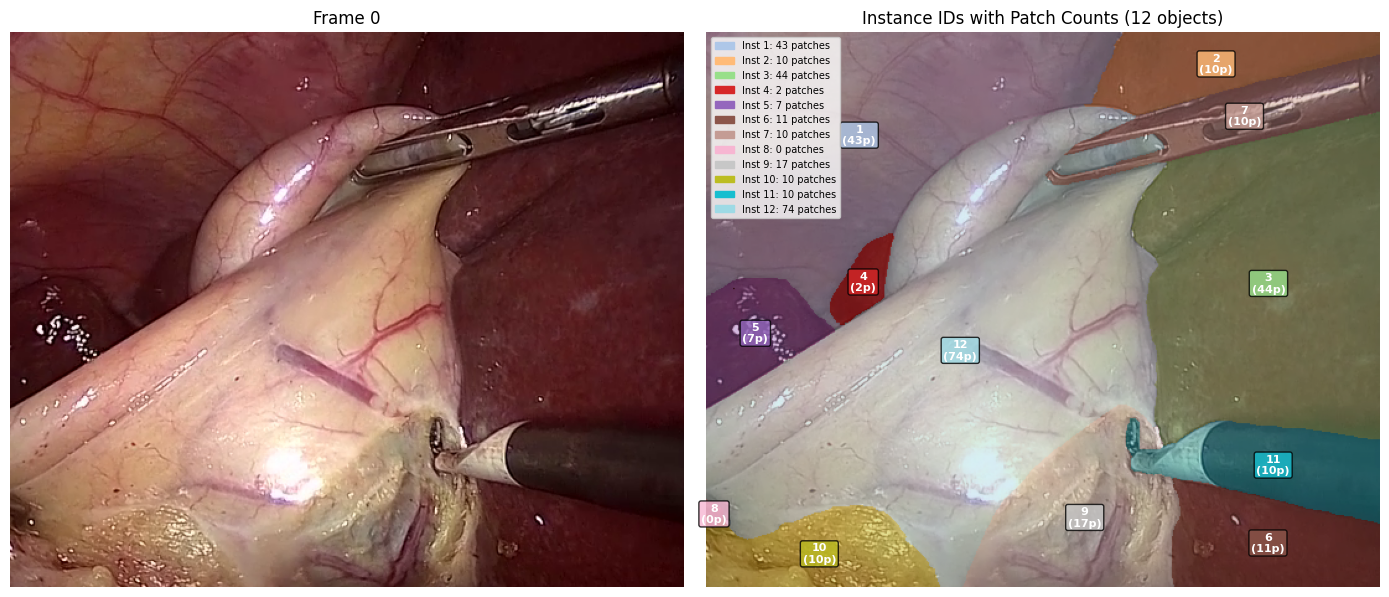

In [31]:
FRAME_IDX = 0

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# File paths
frame_stem = f"{FRAME_IDX:06d}"
patch_feats_path = preprocessed_dir / "qwen3_patch_features" / f"{frame_stem}_f.npy"
patch_map_path = preprocessed_dir / "qwen3_patch_features" / f"{frame_stem}_s.npy"
instance_mask_path = preprocessed_dir / "instance_masks" / f"frame_{frame_stem}.npy"
image_path = preprocessed_dir / "images" / f"frame_{frame_stem}.png"

# Load data
patch_feats = np.load(patch_feats_path)  # (n_patches, hidden_dim * 4)
patch_map = np.load(patch_map_path)  # (1, H, W) - patch index at each pixel
instance_mask = np.load(instance_mask_path)  # (H, W) - instance ID at each pixel
image = Image.open(image_path)
image_np = np.array(image)

print(f"Patch features shape: {patch_feats.shape}")
print(f"Patch map shape: {patch_map.shape}")
print(f"Instance mask shape: {instance_mask.shape}")
print(f"Image shape: {image_np.shape}")

# Remove batch dim from patch_map
patch_map = patch_map[0]  # (H, W)

# Get unique instance IDs (0 = background)
instance_ids = np.unique(instance_mask)
print(f"\nInstance IDs: {instance_ids}")
print(f"Number of instances (including background): {len(instance_ids)}")

# Compute patch grid dimensions and factor
n_patches = patch_feats.shape[0]
H, W = patch_map.shape
# Find patch_h, patch_w such that patch_h * patch_w = n_patches
# factor = H / patch_h = W / patch_w
patch_w = int(np.sqrt(n_patches * W / H))
patch_h = n_patches // patch_w
factor = W // patch_w
print(f"\nPatch grid: {patch_h}x{patch_w}, factor: {factor}")

# Group patches by instance based on patch CENTER falling in mask
instance_to_patches = {inst_id: [] for inst_id in instance_ids}
for p in range(n_patches):
    row = p // patch_w
    col = p % patch_w
    center_y = row * factor + factor // 2
    center_x = col * factor + factor // 2
    
    # Clamp to valid range
    center_y = min(center_y, H - 1)
    center_x = min(center_x, W - 1)
    
    inst_id = instance_mask[center_y, center_x]
    instance_to_patches[inst_id].append(p)

# Convert to arrays
instance_to_patches = {k: np.array(v) for k, v in instance_to_patches.items()}
    
print(f"\nPatch grouping by instance:")
for inst_id, patches in instance_to_patches.items():
    label = "background" if inst_id == 0 else f"instance {inst_id}"
    print(f"  {label}: {len(patches)} patches (indices: {patches[:5]}{'...' if len(patches) > 5 else ''})")

def get_instance_feats(instance_id):
    return patch_feats[instance_to_patches[instance_id]]

# Visualization: overlay instance masks with feature group indices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Original image
axes[0].imshow(image_np)
axes[0].set_title(f"Frame {FRAME_IDX}")
axes[0].axis("off")

# 2. Image with instance masks and centroids labeled by feature group count
cmap = plt.cm.tab20
norm = plt.Normalize(vmin=instance_ids.min(), vmax=max(instance_ids.max(), 1))
instance_colored = cmap(norm(instance_mask))
instance_colored[instance_mask == 0] = [0, 0, 0, 0.3]  # dim background
axes[1].imshow(image_np)
axes[1].imshow(instance_colored, alpha=0.4)

# Add text labels at instance centroids
legend_patches = []
for inst_id in instance_ids:
    if inst_id == 0:
        continue  # skip background
    
    # Compute centroid
    ys, xs = np.where(instance_mask == inst_id)
    cy, cx = ys.mean(), xs.mean()
    
    n_patches = len(instance_to_patches[inst_id])
    color = cmap(norm(inst_id))[:3]
    
    axes[1].text(cx, cy, f"{inst_id}\n({n_patches}p)", 
                 ha='center', va='center', fontsize=8, fontweight='bold',
                 color='white', bbox=dict(boxstyle='round,pad=0.2', 
                                          facecolor=color, alpha=0.8))
    legend_patches.append(mpatches.Patch(color=color, label=f"Inst {inst_id}: {n_patches} patches"))

axes[1].legend(handles=legend_patches, loc='upper left', fontsize=7, framealpha=0.8)
axes[1].set_title(f"Instance IDs with Patch Counts ({len(instance_ids) - 1} objects)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [33]:
# raw feats in correct order

gallbladder_feats = torch.tensor(get_instance_feats(7), device=model.device).float()
grasper_feats = torch.tensor(get_instance_feats(6), device=model.device).float()
liver_feats = torch.tensor(get_instance_feats(3), device=model.device).float()

messages = [
    {"role": "system", "content": [{"type": "text", "text": "Your are a helpful assistant analyzing a cholecystectomy scene."}]},
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Image:"},
            {"type": "image", "image": None},
            {"type": "text", "text": "Which object does the image focus on? (Focus on the image and make your decision based on that.)"},
        ],
    },
]

qwen_utils.generate_with_vision_features(
    messages=messages,
    vision_features=[
        # gallbladder_feats,
        # grasper_feats,
        liver_feats,
    ],
    model=model,
    processor=processor,
    qwen_version="qwen3",
)

'So, let\'s look at the image. It\'s a close-up of a surgical scene, probably laparoscopic since there\'s a scope. The main elements are a red, fleshy area (likely abdominal tissue), and two instruments: one with a clamp or clip (maybe a surgical clamp), and another tool with a rounded end, maybe a dissector or grasping tool. The focus is on the surgical site where they\'re working, so the key object here is the area where the surgery is being performed, specifically the tissue and the instruments used to manipulate it. But the question is asking which object the image focuses on. Let\'s check: the central part is the tissue being operated on, with the instruments around it. In surgical images, the focus is often the operative site. So the main object would be the surgical field, particularly the tissue where the procedure (cholecystectomy, which is gallbladder removal) is happening. Wait, the question says "which object does the image focus on". The image shows the gallbladder area, s